In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
library(randomForest)
library(pheatmap)
library(dbscan)
library(scDblFinder)
suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)



载入程序包：‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing


载入需要的程序包：iterators


载入程序包：‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


载入程序包：‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



载入程序包：‘dbscan’


The following object is masked from ‘package:stats’:

    as.dendrogram


载入需要的程序包：SingleCellExperiment

载入需要的程序包：SummarizedExperiment

载入需要的程序包：MatrixGenerics

载入需要的程序包：matrixStats


载入程序包：‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



载入程序包：‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAn

In [2]:
seurat = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/Macaque_VTA_dataset.rds')

In [ ]:
nonneuron_data = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/datasets/20260904_VTA_nonneuron_cluster.rds')
DA_data = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260807_VTA_DA_seurat_cluster.rds')
neuron_data = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260820_VTA_neuron.rds')

In [3]:
nonneuron_data_new = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/datasets/20260904_VTA_nonneuron_cluster.rds')
nonneuron_data_new

An object of class Seurat 
20344 features across 60696 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [291]:
neuron_data = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260820_VTA_neuron.rds')

In [297]:
merge_seurat <- merge(
    nonneuron_data,
    y = list(DA_data, neuron_data)
)
merge_seurat <- JoinLayers(merge_seurat)

class_resolution <- 0.1

In [299]:

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = merge_seurat@assays$RNA$counts
meta = merge_seurat@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

merge = CreateSeuratObject(counts = new_assay)
merge = AddMetaData(merge, meta)

merge = SCTransform(
    merge, assay="RNA",
    ncells=ncol(merge[["RNA"]]),
    variable.features.n=3000,
    vars.to.regress="percent.mt",
    return.only.var.genes = T,
    method="glmGamPoi"
)

merge = merge %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")


Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19221 by 69777

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 69777 cells

Found 58 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19221 genes

Computing corrected count matrix for 19221 genes

Calculating gene attributes

Wall clock passed: Time difference of 18.43237 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There i

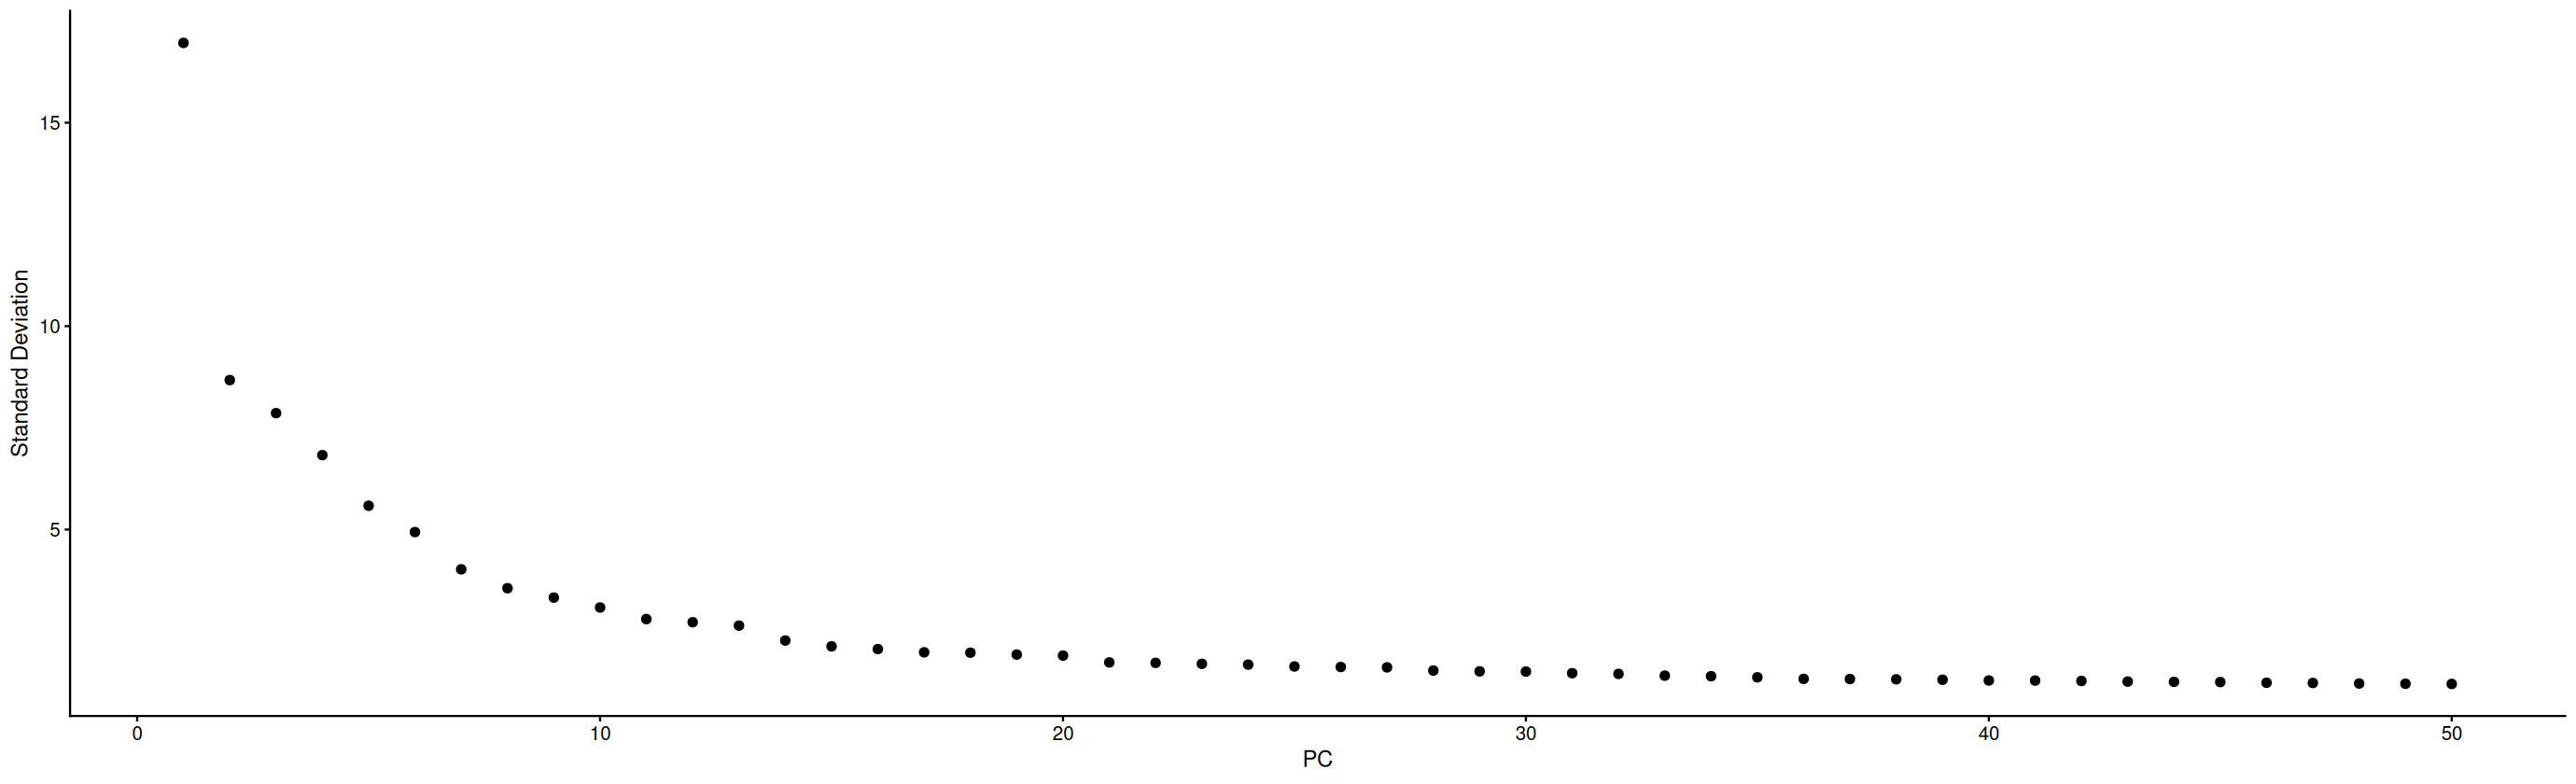

In [71]:
ElbowPlot(merge, ndims = 50)

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations

Computing nearest neighbor graph



Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
01:16:16 UMAP embedding parameters a = 0.9922 b = 1.112

01:16:16 Read 69777 rows and found 25 numeric columns

01:16:16 Using Annoy for neighbor search, n_neighbors = 30

01:16:16 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01:16:24 Writing NN index file to t

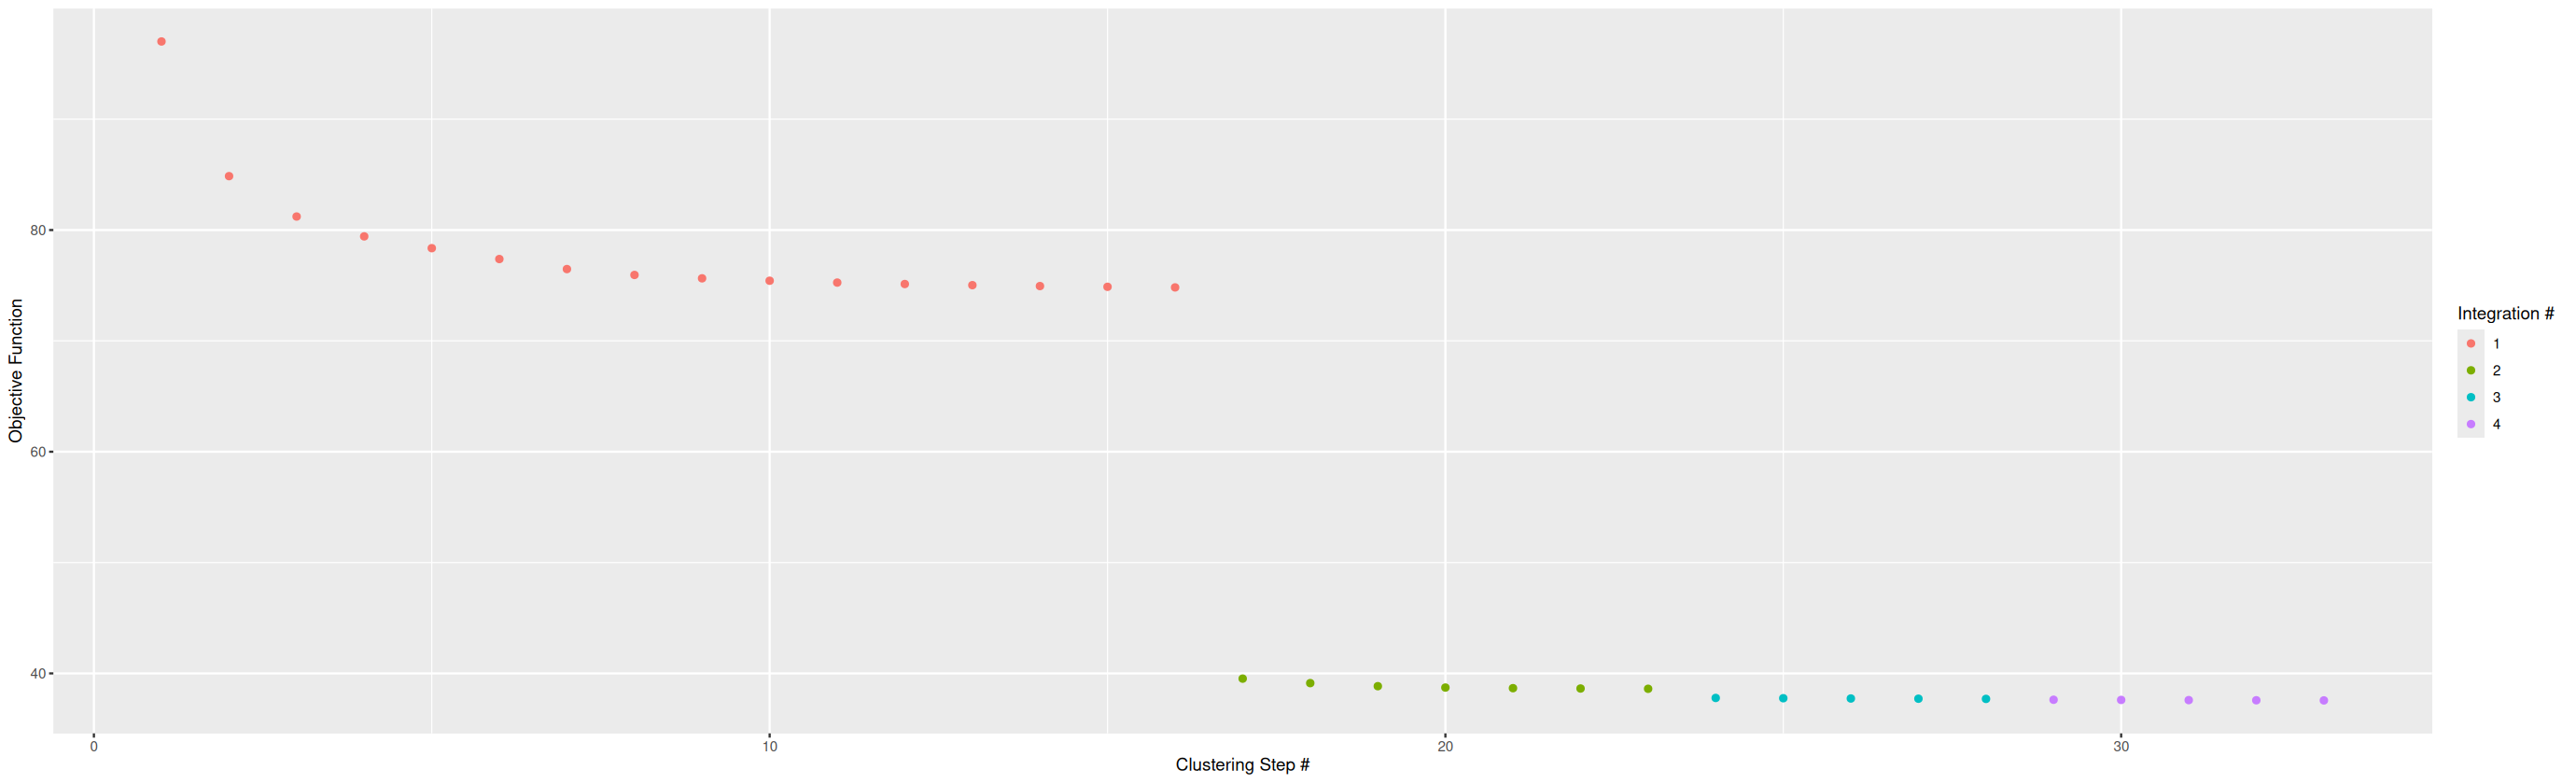

In [300]:

merge = RunHarmony(
    merge, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

merge = merge %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

In [302]:
merge_1 = merge

In [ ]:
options(repr.plot.width=23, repr.plot.height=7)
plot_grid(
    DimPlot(merge_1, reduction="umap", group.by="Class", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(merge_1, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(merge_1, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [ ]:
merge_1$MajorClass <- merge_1$Class

merge_1$MajorClass[merge_1$MajorClass %in% c("Neuron", "DA")] <- "Neuron"

table(merge_1$MajorClass)


 Astro   Endo  Micro Neuron  Oligo    OPC   VLMC 
 13389    582   3932   9081  34198   7881    714 

In [369]:

merge_1$Class[merge_1$Class %in% c("Endotheial")] <- "Endo"
# merge_1$Class[merge_1$Class %in% c("Microglia")] <- "Micro"

# merge_1$Class <- droplevels(merge_1$Class)

table(merge_1$Class)


 Astro     DA   Endo  Micro Neuron  Oligo    OPC   VLMC 
 13389   3461    582   3932   5620  34198   7881    714 

In [383]:
# 各 Animal 中不同 Class 的组成比例（100% 堆积条形图）
class_order <- c("Neuron", "Oligo", "Astro", "OPC", "Micro", "Endo", "VLMC")
class_order <- class_order[class_order %in% unique(as.character(merge_1$Class))]

class_proportions <- merge_1@meta.data %>%
    dplyr::mutate(MajorClass = factor(as.character(MajorClass), levels = class_order)) %>%
    dplyr::count(Animal, MajorClass, name = "n_cells", .drop = FALSE) %>%
    dplyr::group_by(Animal) %>%
    dplyr::mutate(
        percent = n_cells / sum(n_cells) * 100,
        label = sprintf("%.1f%%", percent)
    ) %>%
    dplyr::ungroup()

pdf(
    file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_class_Animal_composition-6.pdf",
    width = 5,
    height = 5
)

options(repr.plot.width = 5, repr.plot.height = 5)

p_class_composition <- ggplot(
    class_proportions,
    aes(x = Animal, y = percent, fill = MajorClass)
) +
    geom_col(width = 0.7, color = "white", linewidth = 0.4) +
    geom_text(
        aes(label = label),
        position = position_stack(vjust = 0.5),
        size = 3
    ) +
    scale_fill_manual(values = class_colors, breaks = class_order, drop = FALSE) +
    scale_y_continuous(
        limits = c(0, 100),
        breaks = seq(0, 100, 25),
        labels = function(x) paste0(x, "%")
    ) +
    labs(x = "Animal", y = "Cell proportion", fill = "MajorClass") +
    theme_classic() +
    theme(
        axis.ticks.x = element_blank(),
        legend.position = "right"
    )

print(p_class_composition)

dev.off()

agg_record_1733341506 
                    2

In [ ]:
class_order = c('Neuron','DA','Oligo','Astro','OPC','Micro','Endothelial','VLMC')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


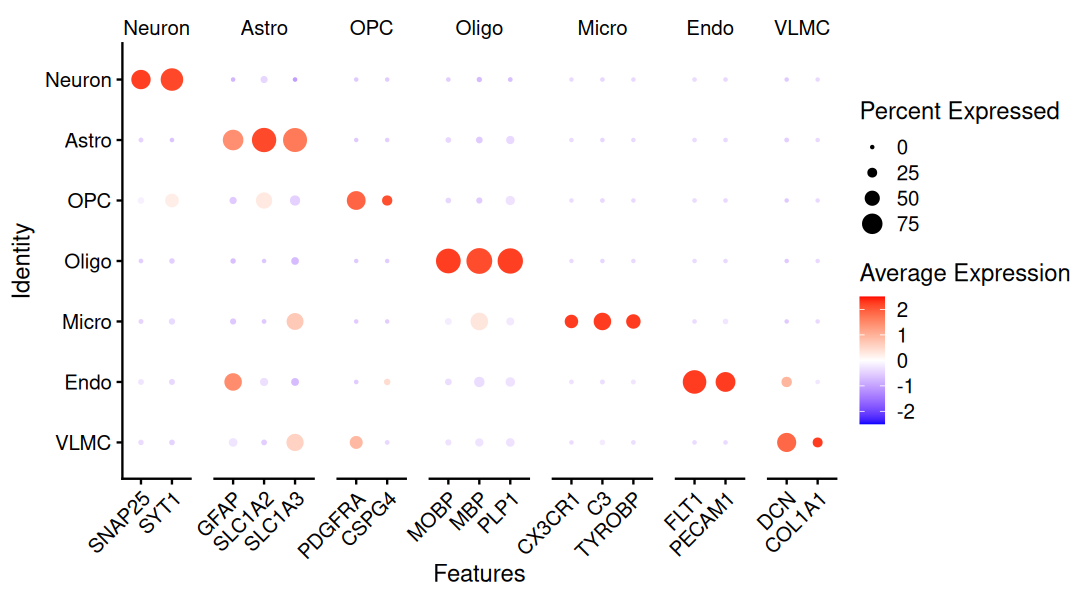

In [384]:
# SCTseurat_harmony_1$Class = SCTseurat_harmony_1$maxPredClass

Neuron= c('SNAP25', 'SYT1')
DA= c('TH',  'SLC18A2', 'DRD2')
# GABA= c('GAD1', 'GAD2', 'SLC32A1')
# Glut= c('SLC17A6', 'SLC17A7', 'SLC17A8')
Astro= c( 'GFAP', 'SLC1A2', 'SLC1A3')
Oligo= c('MOBP', 'MBP', 'PLP1')
OPC= c('PDGFRA', 'CSPG4')
Micro= c('CX3CR1',  'C3', 'TYROBP')
Endo= c( 'FLT1', 'PECAM1')
VLMC= c('DCN', 'COL1A1')

options(repr.plot.height=5,repr.plot.width=9)
class_order = c(
    "VLMC", 
    "Endo",
    # "GABA",
    # "Glut",
    "Micro",
    "Oligo",
    "OPC",
    "Astro",
    "Neuron"
    # "DA"
)
class_order = c(
    class_order[class_order %in% unique(as.character(merge_1$MajorClass))],
    setdiff(unique(as.character(merge_1$MajorClass)), class_order)
)
merge_1$MajorClass = factor(as.character(merge_1$MajorClass), levels = class_order)
Idents(merge_1) = "MajorClass"
features <- list(
    # "DA" = DA,
    "Neuron" = Neuron,
    # "VTA_SNc_DA" = VTA_SNc_DA,
    # "GABA" = GABA,
    # "Glut" = Glut,
    "Astro" = Astro,
    "OPC" = OPC,
    "Oligo" = Oligo,
    "Micro" = Micro,
    "Endo" = Endo,
    "VLMC" = VLMC
)
feature_order = c( "Neuron", "GABA", "Glut", "Astro", "OPC", "Oligo", "Micro", "Endo", "VLMC")
features = features[feature_order[feature_order %in% names(features)]]
features = features[!duplicated(features)]

p_dotplot = DotPlot(merge_1, features = features, cluster.idents = FALSE) +
    RotatedAxis(45) +
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, limits = c(-2.5, 2.5))

print(p_dotplot)


ggsave(
    filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_class_marker_dotplot-3.pdf",
    plot = p_dotplot,
    width = 10,
    height = 5,
    units = "in",
    device = cairo_pdf
)


In [334]:
saveRDS(merge_1, file = '/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260825_VTA_merge.rds')

In [386]:
sampleRatio = 0.8
maxCell = 2000
sampleDf = merge_1@meta.data[, c("MajorClass"), drop=F]
sampleList = split(sampleDf, sampleDf$MajorClass)
sampleList = lapply(sampleList, function(x) {
    sampleSize = as.integer(nrow(x)*0.8)
    if (sampleSize > maxCell) {
        sampleSize = maxCell
    }
    sampleIdx = 1:nrow(x)
    sampleIdx = sample(1:nrow(x), size=sampleSize, replace=F)
    return(x[sampleIdx,,drop=F])
})
sampleDf = Reduce(rbind, sampleList)
str(sampleDf)
table(sampleDf$MajorClass)

'data.frame':	11036 obs. of  1 variable:
 $ MajorClass: Factor w/ 7 levels "VLMC","Endo",..: 1 1 1 1 1 1 1 1 1 1 ...



  VLMC   Endo  Micro  Oligo    OPC  Astro Neuron 
   571    465   2000   2000   2000   2000   2000 

In [387]:
trainSeurat = merge_1[,rownames(sampleDf)]
table(trainSeurat$MajorClass)


  VLMC   Endo  Micro  Oligo    OPC  Astro Neuron 
   571    465   2000   2000   2000   2000   2000 

In [388]:
Idents(trainSeurat) = "MajorClass"
classMarker = FindAllMarkers(trainSeurat)
classMarker = subset(classMarker, p_val_adj < 0.01 & avg_log2FC > 1.0)
table(classMarker$cluster)


Calculating cluster VLMC

Calculating cluster Endo

Calculating cluster Micro

Calculating cluster Oligo

Calculating cluster OPC

Calculating cluster Astro

Calculating cluster Neuron




  VLMC   Endo  Micro  Oligo    OPC  Astro Neuron 
   702   2030   1115    962    770   2107   1753 

In [389]:
trainDf = as.data.frame(t(as.matrix(trainSeurat[["SCT"]]@data[unique(classMarker$gene), ])))
trainDf$MajorClass = trainSeurat$MajorClass
trainDf$MajorClass = factor(trainDf$MajorClass)
# We need to modify the name of the columns
colnames(trainDf) = paste0("col_", colnames(trainDf))
colnames(trainDf) = gsub("-", "_", colnames(trainDf))
colnames(trainDf) = gsub(" ", "_", colnames(trainDf))

rf = randomForest(col_MajorClass~., data=trainDf, ntree=300)

In [394]:
confusionRatio = t(apply(rf$confusion[1:7, 1:7], 1, function(x) {x/sum(x)}))

display_values <- ifelse(confusionRatio > 0.5, sprintf("%.2f", confusionRatio), "")

options(repr.plot.width = 4, repr.plot.height = 4)
pheatmap(
    confusionRatio,
    breaks = seq(0, 1, 0.01),
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    border_color = NA,
    cellwidth = 25,
    cellheight = 25,
    fontsize = 15,
    file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_majorclass_randomForest_confusion-new-1.pdf"

    # display_numbers = display_values
)

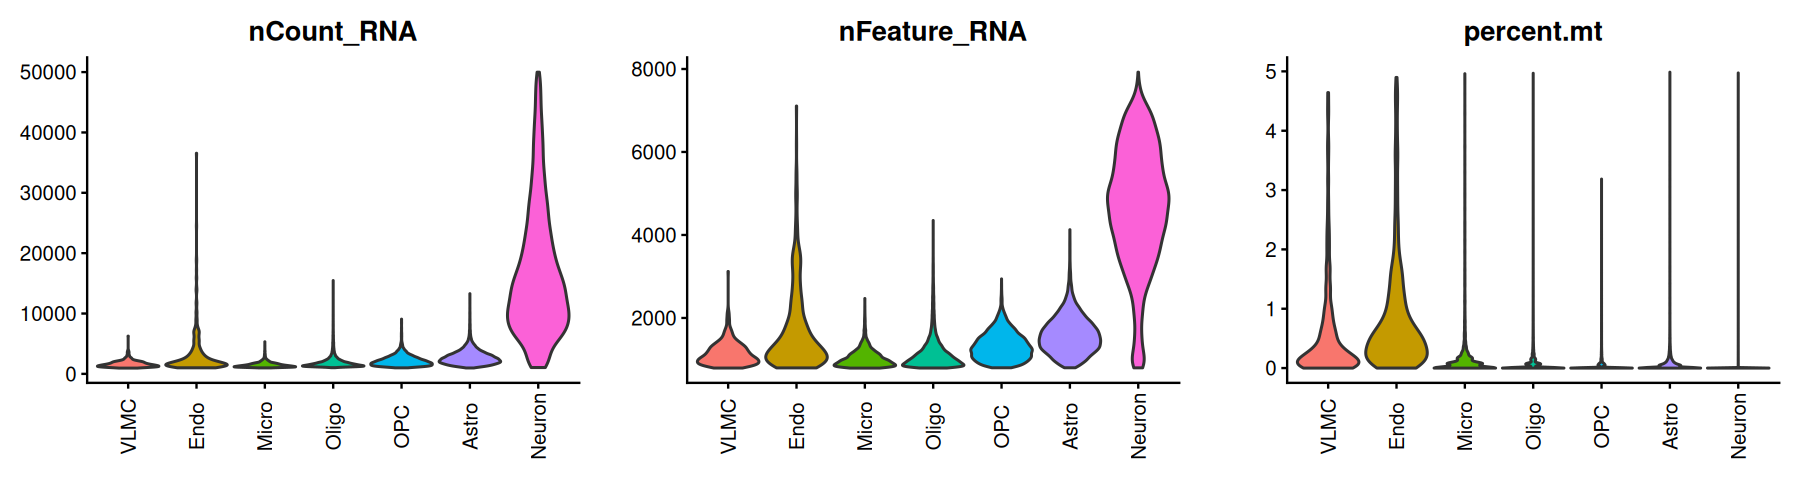

In [441]:
Idents(merge_1) = "MajorClass"
options(repr.plot.width=15, repr.plot.height=4)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt"), function(x) {
        p = VlnPlot(merge_1, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=3, align="hv", axis="tblr"
))

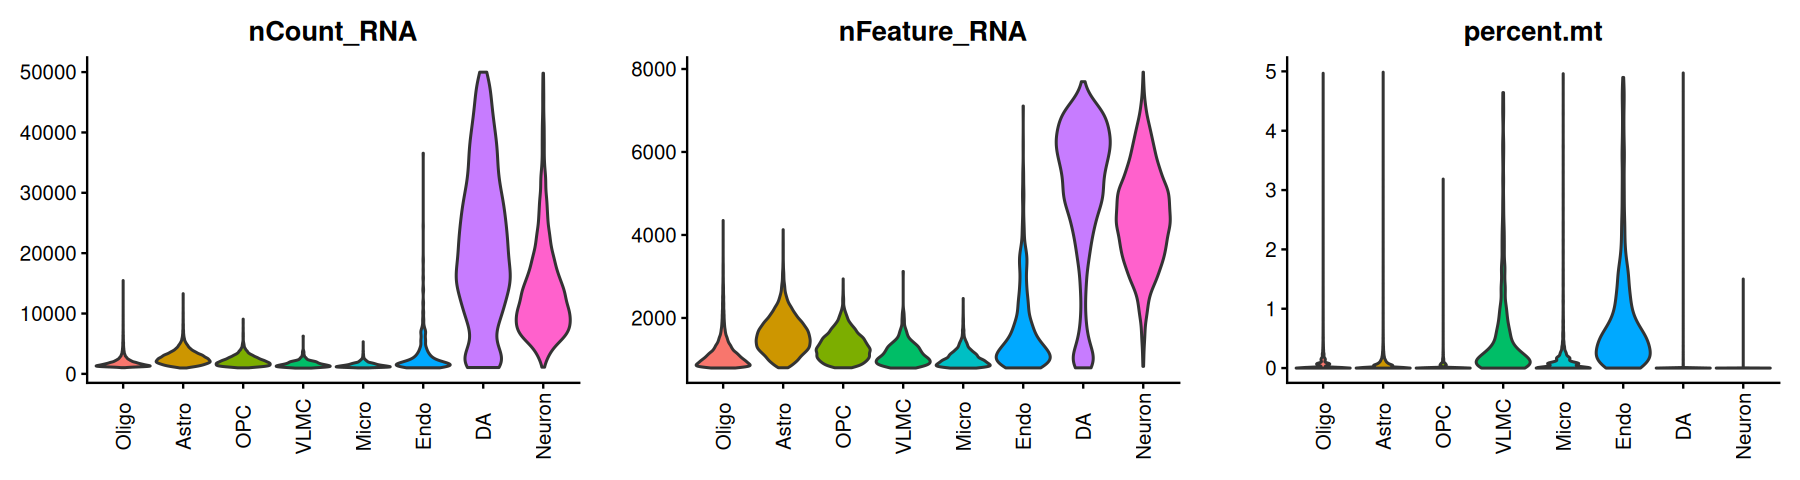

In [444]:
Idents(merge_1) = "Class"
options(repr.plot.width=15, repr.plot.height=4)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt"), function(x) {
        p = VlnPlot(merge_1, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=3, align="hv", axis="tblr"
))

In [443]:
pdf("/mnt/90-connectome/Personal/CQW/midbrain/figure/merge_1_QC_majorclass_violin-1.pdf", width = 15, height = 4)

Idents(merge_1) = "MajorClass"

print(plot_grid(
  plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt"), function(x) {
    p = VlnPlot(
      merge_1,
      features = x,
      pt.size = 0
    ) +
      theme(
        axis.text.x = element_text(
          vjust = 0.5,
          hjust = 0.5,
          angle = 90
        ),
        axis.title.x = element_blank()
      ) +
      guides(fill = "none")
    
    return(p)
  }),
  ncol = 3,
  align = "hv",
  axis = "tblr"
))

dev.off()

agg_record_532449112 
                   2

In [439]:
pdf(file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_majorclass_marker_umap-7.pdf", width = 20, height = 10)

options(repr.plot.width=20, repr.plot.height=10)

FeaturePlot(
merge_1, 
features = c(
    "SNAP25","SLC18A2","GFAP","MOG",
    "PDGFRA","CX3CR1","FLT1","DCN"
    ), 
ncol = 4, 
raster = FALSE,
raster.dpi = c(300, 300),
cols = c("grey", "#ff0000")
)
dev.off()


agg_record_1303556324 
                    2

In [440]:
pdf(
  "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_majorclass_marker_umap-7.pdf",
  width = 20,
  height = 10,
  useDingbats = FALSE
)

FeaturePlot(
  merge_1,
  features = c(
    "SNAP25", "SLC18A2", "GFAP", "MOG",
    "PDGFRA", "CX3CR1", "FLT1", "DCN"
  ),
  ncol = 4,
  raster = TRUE,
  raster.dpi = c(300, 300),
  cols = c("grey", "#ff0000")
)

dev.off()

agg_record_1601820514 
                    2

In [460]:
merge_2 = merge_1

In [5]:
unique(merge_2$cluster)

[1] Oligo_0      Astro_0      Oligo_1      OPC_0        VLMC_0      
 [6] Micro_0      Endo_1       Astro_1      Endo_0       OPC_1       
[11] DA_3         DA_0         DA_8         DA_2         DA_7        
[16] DA_4         DA_6         DA_5         DA_1         GABA_2      
[21] GLUT_GABA_10 GLUT_0       GLUT_GABA_3  GLUT_4       GLUT_GABA_1 
[26] GABA_6       GLUT_9       GLUT_5       GABA_7       GABA_8      
[31] GABA_12      GLUT_11      GABA_13     
33 Levels: Astro_0 Astro_1 DA_0 DA_1 DA_2 DA_3 DA_4 DA_5 DA_6 DA_7 ... VLMC_0

In [6]:
saveRDS(merge_2, '/mnt/90-connectome/Personal/CQW/midbrain/datasets/Macaque_VTA_merge_datasets.rds')

In [2]:
merge_2 = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/datasets/Macaque_VTA_merge_datasets.rds')